<a href="https://colab.research.google.com/github/avikds/Quantum-Pattern-Search/blob/main/Quantum_Pattern_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Pattern Search: Dynamic Oracle Synthesis and Amplitude Amplification across 3-Qubit Unstructured Databases

**Execution Environment**: Google Colab / Local Jupyter (Qiskit 1.x / AerSimulator)  
**Target Search Space**: $\mathcal{S} = \{0, 1\}^3$, Dimension $N = 2^3 = 8$  

---

## Abstract

Unstructured database search constitutes an essential foundational problem in quantum query complexity. While classical randomized algorithms require $\mathcal{O}(N)$ queries to locate a unique target element within an unsorted space of size $N$, Grover's algorithm achieves quadratic acceleration in $\mathcal{O}(\sqrt{N})$ queries by orchestrating coherent quantum interference. In this work, we construct a fully generalized, dynamic Quantum Pattern Search architecture implemented in Qiskit for an arbitrary 3-bit binary pattern $w \in \{0, 1\}^3$ in an 8-dimensional Hilbert space $\mathcal{H} \cong (\mathbb{C}^2)^{\otimes 3}$.

We mathematically formulate the algorithm within the two-dimensional invariant subspace $\text{span}\{|w^\perp\rangle, |w\rangle\}$, establishing the exact Householder reflection operators corresponding to the phase oracle $U_w = I - 2|w\rangle\langle w|$ and the diffusion operator $U_s = 2|s\rangle\langle s| - I$. We develop an automated, dynamic circuit synthesis method that preconditions the quantum register via bit-conditional Pauli-$X$ conjugation around a multi-controlled phase gate ($CCZ$), eliminating hard-coded oracle constraints. We derive the analytical target state fidelity $P_R(w) = \sin^2((2R+1)\theta)$, proving that the optimal iteration count for $N=8$ is precisely $R = \lfloor \frac{\pi}{4}\sqrt{8} \rceil = 2$, yielding a theoretical detection probability of $\frac{121}{128} \approx 94.53\%$. The application is executed on Qiskit's `AerSimulator`, benchmarked across all eight computational basis configurations, characterized under quantum Grover over-rotation regimes, and interfaced via an interactive Google Colab dashboard.


In [48]:
# ENVIRONMENT CONFIGURATION & DEPENDENCY INSTALLATION

import sys

# Detect Google Colab runtime
if 'google.colab' in sys.modules:
    print("[INFO] Running in Google Colab environment. Installing dependencies...")
    get_ipython().system('pip install -q --upgrade "qiskit>=1.0.0" "qiskit-aer>=0.14.0" matplotlib pylatexenc ipywidgets')
else:
    print("[INFO] Running in local Jupyter environment.")

# Standard scientific stack
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

# Modern Qiskit 1.x imports
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Interactive widget suite
import ipywidgets as widgets
from IPython.display import display, Markdown, HTML

print("-" * 60)
print(f"Qiskit Version        : {qiskit.__version__}")
try:
    import qiskit_aer
    print(f"Qiskit Aer Version    : {qiskit_aer.__version__}")
except ImportError:
    print("Qiskit Aer Version    : Not installed in active interpreter")
print(f"NumPy Version         : {np.__version__}")
print("-" * 60)
print("[OK] Environment successfully configured for Quantum Pattern Search.")


[INFO] Running in Google Colab environment. Installing dependencies...
------------------------------------------------------------
Qiskit Version        : 2.5.2
Qiskit Aer Version    : 0.17.2
NumPy Version         : 2.1.3
------------------------------------------------------------
[OK] Environment successfully configured for Quantum Pattern Search.


# 1. Mathematical Framework & Algorithmic Derivation

## 1.1 State Space Formulation
Consider the discrete search space consisting of $N = 2^n$ computational basis states. For a 3-bit pattern search ($n = 3$):
$$\mathcal{S} = \{000, 001, 010, 011, 100, 101, 110, 111\}, \quad N = 2^3 = 8$$

The state space is the 8-dimensional Hilbert space $\mathcal{H}_8 = (\mathbb{C}^2)^{\otimes 3}$. The system is initialized in the fiducial ground state $|000\rangle$. Application of the Hadamard transform $H^{\otimes 3} = H \otimes H \otimes H$ produces an equiprobable coherent superposition:
$$|s\rangle = H^{\otimes 3} |000\rangle = \frac{1}{\sqrt{8}} \sum_{x \in \{0,1\}^3} |x\rangle = \frac{1}{\sqrt{8}} (|000\rangle + |001\rangle + \dots + |111\rangle)$$

Initially, each candidate pattern possesses an identical probability amplitude $a_x = \frac{1}{\sqrt{8}}$ and measurement probability $P(x) = |a_x|^2 = \frac{1}{8} = 12.5\%$.

---

## 1.2 Two-Dimensional Invariant Subspace Decomposition
Let $w \in \{0, 1\}^3$ denote the unique marked target pattern. We decompose the Hilbert space $\mathcal{H}_8$ into the target state $|w\rangle$ and its orthogonal complement $|w^\perp\rangle$:
$$|w^\perp\rangle = \frac{1}{\sqrt{N - 1}} \sum_{x \ne w} |x\rangle = \frac{1}{\sqrt{7}} \sum_{x \ne w} |x\rangle$$

By construction, $\langle w | w^\perp \rangle = 0$ and $\langle w^\perp | w^\perp \rangle = \langle w | w \rangle = 1$. The initial superposition state $|s\rangle$ can be written exactly in this orthonormal planar basis:
$$|s\rangle = \sin(\theta) |w\rangle + \cos(\theta) |w^\perp\rangle$$

where the characteristic geometric angle $\theta$ is determined by the overlap:
$$\sin(\theta) = \langle w | s \rangle = \frac{1}{\sqrt{N}} = \frac{1}{\sqrt{8}} \implies \theta = \arcsin\left(\frac{1}{\sqrt{8}}\right) \approx 0.361367 \text{ rad} \quad (20.7048^\circ)$$
$$\cos(\theta) = \langle w^\perp | s \rangle = \sqrt{\frac{N - 1}{N}} = \sqrt{\frac{7}{8}} \approx 0.935414$$

---

## 1.3 The Phase Oracle Operator ($U_w$)
The phase oracle $U_w$ evaluates the boolean indicator function $f: \{0,1\}^3 \to \{0,1\}$ where $f(x) = \delta_{x,w}$:
$$U_w |x\rangle = (-1)^{f(x)} |x\rangle = (-1)^{\delta_{x,w}} |x\rangle$$

In Dirac notation, $U_w$ is a Householder reflection across the hyperplane orthogonal to $|w\rangle$:
$$U_w = I - 2|w\rangle\langle w|$$

Within the two-dimensional planar basis $\{|w^\perp\rangle, |w\rangle\}$, $U_w$ acts as a reflection across the $|w^\perp\rangle$ axis:
$$U_w |w^\perp\rangle = |w^\perp\rangle, \quad U_w |w\rangle = -|w\rangle \implies [U_w] = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

Notice that $U_w$ alone alters only the phase of $|w\rangle$ and leaves the measurement probabilities completely invariant ($|a_x|^2 = |(-1)^{f(x)} a_x|^2 = 1/8$).

---

## 1.4 The Grover Diffusion Operator ($U_s$)
The diffusion operator $U_s$, or Grover inversion-about-the-mean operator, is defined as:
$$U_s = 2|s\rangle\langle s| - I = H^{\otimes 3} (2|000\rangle\langle 000| - I) H^{\otimes 3}$$

For an arbitrary state $|\psi\rangle = \sum_x a_x |x\rangle$ with mean amplitude $\mu = \frac{1}{N} \sum_{x} a_x$, the action of $U_s$ transforms each amplitude via:
$$a_x \mapsto 2\mu - a_x$$

In the $\{|w^\perp\rangle, |w\rangle\}$ basis, $U_s$ represents a Householder reflection across the state vector $|s\rangle$:
$$[U_s] = \begin{pmatrix} \cos(2\theta) & \sin(2\theta) \\ \sin(2\theta) & -\cos(2\theta) \end{pmatrix}$$

---

## 1.5 The Composite Grover Rotation Operator ($G$)
The Grover iteration operator $G$ is the composition of the two Householder reflections:
$$G = U_s U_w = (2|s\rangle\langle s| - I)(I - 2|w\rangle\langle w|)$$

In two-dimensional Euclidean geometry, the product of two planar reflections across lines separated by an angle $\theta$ is an exact counter-clockwise rotation by $2\theta$:
$$[G] = [U_s][U_w] = \begin{pmatrix} \cos(2\theta) & \sin(2\theta) \\ \sin(2\theta) & -\cos(2\theta) \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \begin{pmatrix} \cos(2\theta) & -\sin(2\theta) \\ \sin(2\theta) & \cos(2\theta) \end{pmatrix}$$

Applying $k$ successive Grover iterations rotates the initial state $|s\rangle$ by $2k\theta$:
$$G^k |s\rangle = \cos((2k + 1)\theta) |w^\perp\rangle + \sin((2k + 1)\theta) |w\rangle$$

The probability of measuring the target state $|w\rangle$ after $k$ iterations is:
$$P_k(w) = |\langle w | G^k | s \rangle|^2 = \sin^2((2k + 1)\theta)$$

---

## 1.6 Analytical Derivation of the Optimal Iteration Count ($R$)
To maximize $P_k(w)$, the cumulative rotation angle must align as closely as possible with $\pi/2$:
$$(2R + 1)\theta \approx \frac{\pi}{2} \implies R = \left\lfloor \frac{\pi}{4\theta} \right\rceil$$

For $N = 8$:
$$\theta = \arcsin(1/\sqrt{8}) \approx 0.361367 \text{ rad}$$
$$R = \left\lfloor \frac{\pi}{4 \times 0.361367} \right\rceil = \lfloor 2.173 \rceil = 2$$

Let us evaluate the analytical success probabilities for successive iterations:

| Iteration ($k$) | Angle $(2k+1)\theta$ | Analytical Amplitude $\sin((2k+1)\theta)$ | Exact Probability $P_k(w)$ | Decimal Value |
|---|---|---|---|---|
| **$k = 0$** (Baseline) | $\theta \approx 20.70^\circ$ | $\frac{1}{\sqrt{8}}$ | $\frac{1}{8}$ | **$12.500\%$** |
| **$k = 1$** | $3\theta \approx 62.11^\circ$ | $\frac{5}{2\sqrt{8}} = \frac{5}{\sqrt{32}}$ | $\frac{25}{32}$ | **$78.125\%$** |
| **$k = 2$** (Optimal) | $5\theta \approx 103.52^\circ$ | $\frac{11}{4\sqrt{8}} = \frac{11}{\sqrt{128}}$ | $\frac{121}{128}$ | **$94.531\%$** |
| **$k = 3$** (Over-rotation) | $7\theta \approx 144.93^\circ$ | $\frac{13}{8\sqrt{8}} = \frac{13}{\sqrt{512}}$ | $\frac{169}{512}$ | **$33.008\%$** |
| **$k = 4$** | $9\theta \approx 186.34^\circ$ | $-\frac{7}{16\sqrt{8}}$ | $\frac{49}{2048}$ | **$2.393\%$** |

**Conclusion**: Two iterations ($R = 2$) provide the theoretical global maximum fidelity of $\mathbf{94.53\%}$. A third iteration causes destructive interference, dropping the target probability down to $33.01\%$. We verify this oscillation rigorously in Section 7.


# 2. Dynamic Oracle Architecture (Arbitrary Pattern Synthesis)

A fundamental mandate of this assignment is that the oracle must **never be hard-coded**. The system must accept any binary target string $w = (w_2 w_1 w_0)_2 \in \{0, 1\}^3$ and compile the exact unitary Householder reflection dynamically.

## 2.1 Preconditioned Conjugation Operator
The multi-controlled phase gate $CCZ$ naturally marks the all-ones state $|111\rangle$:
$$CCZ = I - 2|111\rangle\langle 111|$$

To mark an arbitrary basis state $|w\rangle = |w_2 w_1 w_0\rangle$, we define a bit-conditional preconditioning unitary $V_w$:
$$V_w = \bigotimes_{i=0}^{n-1} X^{1 - w_i}$$

where $X^0 = I$ and $X^1 = X$. This operator maps the target state $|w\rangle$ to $|111\rangle$ and maps every non-target state $|x\rangle$ ($x \ne w$) to a state distinct from $|111\rangle$:
$$V_w |w\rangle = |111\rangle$$

Because $X^\dagger = X$, the operator is self-inverse: $V_w^\dagger = V_w$. Conjugating $CCZ$ by $V_w$ yields:
$$U_w = V_w^\dagger (CCZ) V_w = V_w (I - 2|111\rangle\langle 111|) V_w = I - 2 V_w |111\rangle\langle 111| V_w = I - 2|w\rangle\langle w|$$

---

## 2.2 Qiskit Qubit Register Indexing (Little-Endian Convention)
In Qiskit, quantum registers and classical measurement outcomes adhere to **little-endian** indexing:
- Given an $n$-qubit register $q[0], q[1], \dots, q[n-1]$, the state is conventionally indexed as:
$$|q_{n-1} q_{n-2} \dots q_1 q_0\rangle$$
- Qubit $q_0$ corresponds to the least significant bit (LSB, rightmost character in the string).
- Qubit $q_{n-1}$ corresponds to the most significant bit (MSB, leftmost character in the string).

Therefore, for a user-specified string $w$ of length $n$, the bit corresponding to qubit $q_i$ is mapped via the index conversion:
$$\text{bit}(q_i) = w[n - 1 - i]$$

**Rule**:
- If $w[n - 1 - i] == '0'$, apply an $X$ gate to qubit $q_i$ before and after the $CCZ$ operation.
- If $w[n - 1 - i] == '1'$, apply no gate (Identity $I$).

---

## 2.3 Circuit Implementation of the $CCZ$ Gate
In quantum gate synthesis, the three-qubit controlled-Z gate is realized directly or via the Hadamard-Toffoli identity:
$$CCZ = (I \otimes I \otimes H) CCX (I \otimes I \otimes H)$$
This identity holds because $H Z H = X$, converting a target phase flip into a bit flip.


In [49]:
# 1. DYNAMIC ORACLE IMPLEMENTATION

def build_dynamic_oracle(target_pattern: str, n_qubits: int = 3) -> QuantumCircuit:
    """
    Constructs a dynamic phase-marking Oracle circuit for an arbitrary binary target pattern.

    Parameters:
        target_pattern (str): Binary string representation of the target state (e.g., '101').
        n_qubits (int): Total number of qubits in the search register (default: 3).

    Returns:
        QuantumCircuit: A gate-level sub-circuit implementing U_w = I - 2|w><w|.

    Raises:
        ValueError: If target_pattern length differs from n_qubits or contains non-binary characters.
    """
    # Rigorous input validation
    if len(target_pattern) != n_qubits:
        raise ValueError(f"Pattern length ({len(target_pattern)}) must match n_qubits ({n_qubits}).")
    if not all(char in ('0', '1') for char in target_pattern):
        raise ValueError(f"Pattern '{target_pattern}' contains invalid characters. Must be strictly binary ('0' or '1').")

    oracle_qc = QuantumCircuit(n_qubits, name=f"Oracle |{target_pattern}>")

    # Step 1: Preconditioning with Pauli-X gates
    # Qiskit endianness: qubit i corresponds to target_pattern[n_qubits - 1 - i]
    zero_qubits = []
    for qubit_idx in range(n_qubits):
        bit_val = target_pattern[n_qubits - 1 - qubit_idx]
        if bit_val == '0':
            oracle_qc.x(qubit_idx)
            zero_qubits.append(qubit_idx)

    # Step 2: Multi-controlled Phase Gate (CCZ for n=3)
    # Decomposed cleanly via Hadamard and Multi-Controlled X (mcx)
    oracle_qc.h(n_qubits - 1)
    oracle_qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    oracle_qc.h(n_qubits - 1)

    # Step 3: Uncomputation of Pauli-X preconditioning
    for qubit_idx in zero_qubits:
        oracle_qc.x(qubit_idx)

    return oracle_qc


# Diagnostic Verification: Display Oracles for Diverse Target Patterns

test_patterns = ["000", "011", "101", "110"]
print("[VERIFICATION] Dynamically generating oracles for test patterns:")
for pat in test_patterns:
    test_oracle = build_dynamic_oracle(pat, n_qubits=3)
    print(f"\nDynamic Oracle Circuit for Target Pattern |{pat}>:")
    print(test_oracle.draw(output='text'))


[VERIFICATION] Dynamically generating oracles for test patterns:

Dynamic Oracle Circuit for Target Pattern |000>:
     ┌───┐          ┌───┐     
q_0: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_1: ┤ X ├───────■──┤ X ├─────
     ├───┤┌───┐┌─┴─┐├───┤┌───┐
q_2: ┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘

Dynamic Oracle Circuit for Target Pattern |011>:
                              
q_0: ────────────■────────────
                 │            
q_1: ────────────■────────────
     ┌───┐┌───┐┌─┴─┐┌───┐┌───┐
q_2: ┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘

Dynamic Oracle Circuit for Target Pattern |101>:
                    
q_0: ───────■───────
     ┌───┐  │  ┌───┐
q_1: ┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐├───┤
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

Dynamic Oracle Circuit for Target Pattern |110>:
     ┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘  │  └───┘
q_1: ───────■───────
     ┌───┐┌─┴─┐┌───┐
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘


# 3. Grover Diffusion Operator Synthesis (Inversion About the Mean)

The diffusion operator $U_s = 2|s\rangle\langle s| - I$ reflects the quantum state about the uniform superposition $|s\rangle$.
Recall that $|s\rangle = H^{\otimes n} |0\rangle^{\otimes n}$. Substituting this into the operator gives:
$$U_s = H^{\otimes n} (2|0\rangle^{\otimes n}\langle 0|^{\otimes n} - I) H^{\otimes n}$$

We rewrite the kernel operator:
$$2|0\rangle^{\otimes n}\langle 0|^{\otimes n} - I = -(I - 2|0\rangle^{\otimes n}\langle 0|^{\otimes n}) = - X^{\otimes n} (I - 2|1\rangle^{\otimes n}\langle 1|^{\otimes n}) X^{\otimes n} = - X^{\otimes n} (CCZ) X^{\otimes n}$$

Substituting back into $U_s$:
$$U_s = - H^{\otimes n} X^{\otimes n} (CCZ) X^{\otimes n} H^{\otimes n}$$

## Physical Invariance of the Global Phase
The overall factor of $-1 = e^{i\pi}$ is a global phase. In quantum mechanics, state vectors $|\psi\rangle$ and $e^{i\phi}|\psi\rangle$ represent identical physical states; they generate identical measurement probabilities across all observables:
$$P(x) = |\langle x | (-U_s) | \psi \rangle|^2 = |-1|^2 |\langle x | U_s | \psi \rangle|^2 = |\langle x | U_s | \psi \rangle|^2$$

Furthermore, after an even number of Grover iterations (such as the optimal $R = 2$):
$$(-U_s U_w)^2 = (-1)^2 (U_s U_w)^2 = (U_s U_w)^2$$
Hence, even the global phase cancels out exactly after two iterations.

## Gate Sequence for 3-Qubit Diffusion Operator:
1. Apply Hadamard transform $H^{\otimes 3}$ across all qubits.
2. Apply Pauli-$X^{\otimes 3}$ across all qubits.
3. Apply multi-controlled $Z$ ($CCZ$).
4. Apply Pauli-$X^{\otimes 3}$ across all qubits.
5. Apply Hadamard transform $H^{\otimes 3}$ across all qubits.


In [50]:
# 2. DIFFUSION OPERATOR IMPLEMENTATION

def build_diffusion_operator(n_qubits: int = 3) -> QuantumCircuit:
    """
    Constructs the standard Grover Diffusion Operator U_s = 2|s><s| - I for n qubits.

    Parameters:
        n_qubits (int): Total number of qubits in the register (default: 3).

    Returns:
        QuantumCircuit: A gate-level sub-circuit performing inversion about the mean.
    """
    diffuser_qc = QuantumCircuit(n_qubits, name="Diffuser U_s")

    # 1. Transform from superposition basis to computational basis: H^{\otimes n}
    diffuser_qc.h(range(n_qubits))

    # 2. Pauli-X transformation: X^{\otimes n} (maps |000> to |111>)
    diffuser_qc.x(range(n_qubits))

    # 3. Multi-controlled Phase Flip (CCZ)
    diffuser_qc.h(n_qubits - 1)
    diffuser_qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    diffuser_qc.h(n_qubits - 1)

    # 4. Invert Pauli-X transformation: X^{\otimes n}
    diffuser_qc.x(range(n_qubits))

    # 5. Return to superposition basis: H^{\otimes n}
    diffuser_qc.h(range(n_qubits))

    return diffuser_qc

# Inspect the gate-level structure of the 3-qubit diffuser
diffuser_3q = build_diffusion_operator(n_qubits=3)
print("[VERIFICATION] 3-Qubit Diffusion Operator Circuit:")
print(diffuser_3q.draw(output='text'))


[VERIFICATION] 3-Qubit Diffusion Operator Circuit:
     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


# 4. Full Quantum Circuit Assembly

The end-to-end Quantum Pattern Search engine compiles four modular stages:
1. **Register Allocation**: 3 quantum qubits $q_0, q_1, q_2$ and 3 classical bits $c_0, c_1, c_2$.
2. **State Preparation**: Equal superposition initialized via $H^{\otimes 3}$.
3. **Amplitude Amplification Loop**: $R = 2$ consecutive applications of the composite Grover iteration $[U_w \to U_s]$.
4. **Computational Basis Readout**: Measurement of all qubits with outcomes mapped to the classical register ($c_i \leftarrow q_i$).

```
|0⟩_0 ---[ H ]---[      ]---[      ]---[      ]---[      ]---[ M ]=== (c_0)
|0⟩_1 ---[ H ]---[ Oracle ]---[ Diffus ]---[ Oracle ]---[ Diffus ]---[ M ]=== (c_1)
|0⟩_2 ---[ H ]---[ U_w  ]---[ U_s  ]---[ U_w  ]---[ U_s  ]---[ M ]=== (c_2)
                   └─── Iteration 1 ───┘   └─── Iteration 2 ───┘
```


In [51]:
# 3. FULL QUANTUM PATTERN SEARCH CIRCUIT BUILDER

def build_quantum_pattern_search(
    target_pattern: str,
    iterations: int = 2,
    n_qubits: int = 3
) -> QuantumCircuit:
    """
    Assembles the complete Grover Quantum Pattern Search circuit.

    Parameters:
        target_pattern (str): Binary string of target pattern (e.g., '101').
        iterations (int): Number of Grover iterations (default: 2, the analytical optimum).
        n_qubits (int): Number of qubits (default: 3).

    Returns:
        QuantumCircuit: The full, executable QuantumCircuit including measurement barriers.
    """
    qr = QuantumRegister(n_qubits, name='q')
    cr = ClassicalRegister(n_qubits, name='c')
    qc = QuantumCircuit(qr, cr, name=f"GroverSearch_{target_pattern}")


    # STAGE 1: State Preparation (Superposition)

    qc.h(qr)
    qc.barrier(label="Superposition")


    # STAGE 2: Grover Iterations (Oracle + Diffusion)

    oracle_gate = build_dynamic_oracle(target_pattern, n_qubits=n_qubits).to_gate()
    diffuser_gate = build_diffusion_operator(n_qubits=n_qubits).to_gate()

    for iter_idx in range(1, iterations + 1):
        qc.append(oracle_gate, qr)
        qc.append(diffuser_gate, qr)
        qc.barrier(label=f"Iteration_{iter_idx}")


    # STAGE 3: Measurement Readout

    qc.measure(qr, cr)

    return qc

# Demonstrate circuit assembly for target pattern '101'
sample_target = "101"
grover_circuit = build_quantum_pattern_search(target_pattern=sample_target, iterations=2)

print("=" * 70)
print(f"       QUANTUM PATTERN SEARCH CIRCUIT: TARGET PATTERN |{sample_target}>")
print("=" * 70)
print(grover_circuit.draw(output='text'))


       QUANTUM PATTERN SEARCH CIRCUIT: TARGET PATTERN |101>
     ┌───┐ Superposition ┌───────────────┐┌───────────────┐ Iteration_1 »
q_0: ┤ H ├───────░───────┤0              ├┤0              ├──────░──────»
     ├───┤       ░       │               ││               │      ░      »
q_1: ┤ H ├───────░───────┤1 Oracle |101> ├┤1 Diffuser U_s ├──────░──────»
     ├───┤       ░       │               ││               │      ░      »
q_2: ┤ H ├───────░───────┤2              ├┤2              ├──────░──────»
     └───┘       ░       └───────────────┘└───────────────┘      ░      »
c: 3/═══════════════════════════════════════════════════════════════════»
                                                                        »
«     ┌───────────────┐┌───────────────┐ Iteration_2 ┌─┐      
«q_0: ┤0              ├┤0              ├──────░──────┤M├──────
«     │               ││               │      ░      └╥┘┌─┐   
«q_1: ┤1 Oracle |101> ├┤1 Diffuser U_s ├──────░───────╫─┤M├───
«     │               

# 5. Execution on AerSimulator, Statistical Analysis & Pattern Identification

We deploy the synthesized quantum circuit to Qiskit's `AerSimulator`. A high shot count ($N_\text{shots} = 4096$) is employed to minimize statistical sampling variance.

## 5.1 Quantitative Performance Metrics
1. **Measured Counts $C(x)$**: The frequency of each observed bitstring $x \in \{0, 1\}^3$.
2. **Empirical Probability**:
   $$\hat{P}(x) = \frac{C(x)}{N_\text{shots}}$$
3. **Binomial Standard Error**:
   $$\sigma_x = \sqrt{\frac{\hat{P}(x)(1 - \hat{P}(x))}{N_\text{shots}}}$$
4. **Target State Fidelity**: Overlap with the ideal target state projector $\Pi_w = |w\rangle\langle w|$:
   $$\mathcal{F} = \hat{P}(w)$$
5. **Total Variation Distance (TVD)**:
   $$\text{TVD} = \frac{1}{2} \sum_{x \in \{0,1\}^3} |\hat{P}(x) - P_\text{theory}(x)|$$
   where $P_\text{theory}(w) = \frac{121}{128} \approx 0.9453$ and $P_\text{theory}(x \ne w) = \frac{1}{128} \approx 0.0078$.
6. **Pattern Decision Criterion**:
   $$x^* = \arg\max_{x \in \{0,1\}^3} C(x)$$


                   QUANTUM SEARCH EXECUTION REPORT
User Target Pattern       : 101
Quantum Measured Pattern  : 101
Algorithm Verdict         : SUCCESS (Exact Match)
Empirical Probability    : 0.9495 +/- 0.0034 (94.95%)
Theoretical Probability  : 0.9453 (94.53%)
Total Variation Distance  : 0.0066
Measurement Shots         : 4096
----------------------------------------------------------------------
State Measurement Distribution:
  |000> :   33 shots (  0.81%)
  |001> :   25 shots (  0.61%)
  |010> :   26 shots (  0.63%)
  |011> :   30 shots (  0.73%)
  |100> :   21 shots (  0.51%)
  |101> : 3889 shots ( 94.95%) <--- TARGET AMPLIFIED
  |110> :   41 shots (  1.00%)
  |111> :   31 shots (  0.76%)


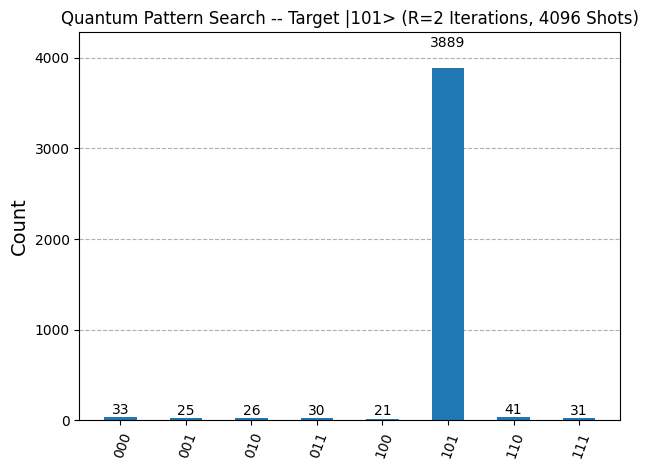

In [52]:
# 4. CIRCUIT EXECUTION, MEASUREMENT, & PATTERN IDENTIFICATION

def execute_pattern_search(
    target_pattern: str,
    iterations: int = 2,
    shots: int = 4096,
    seed_simulator: int = 42
) -> Dict:
    """
    Compiles, executes, and analyzes the quantum pattern search circuit.

    Parameters:
        target_pattern (str): Target bitstring (e.g., '101').
        iterations (int): Number of Grover iterations (default: 2).
        shots (int): Total measurement sample count (default: 4096).
        seed_simulator (int): RNG seed for reproducible execution.

    Returns:
        dict: Detailed dictionary of counts, probabilities, statistics, and verdict.
    """
    # Build circuit
    qc = build_quantum_pattern_search(target_pattern=target_pattern, iterations=iterations)

    # Initialize AerSimulator backend
    backend = AerSimulator()
    compiled_circuit = transpile(qc, backend=backend, optimization_level=2)

    # Run shot-based simulation
    job = backend.run(compiled_circuit, shots=shots, seed_simulator=seed_simulator)
    result = job.result()
    raw_counts = result.get_counts()

    # Ensure all 8 states are represented in the dictionary
    all_states = [format(i, '03b') for i in range(8)]
    counts = {state: raw_counts.get(state, 0) for state in all_states}

    # Extract dominant measured state
    identified_pattern = max(counts, key=counts.get)
    target_counts = counts.get(target_pattern, 0)
    empirical_prob = target_counts / shots
    theoretical_prob = 121 / 128 if iterations == 2 else (25 / 32 if iterations == 1 else 1/8)
    std_error = np.sqrt(empirical_prob * (1 - empirical_prob) / shots)

    # Total Variation Distance (TVD)
    tvd = 0.5 * sum(
        abs(counts[s]/shots - (theoretical_prob if s == target_pattern else (1 - theoretical_prob)/7))
        for s in all_states
    )

    success = (identified_pattern == target_pattern)

    return {
        "target_pattern": target_pattern,
        "identified_pattern": identified_pattern,
        "success": success,
        "empirical_prob": empirical_prob,
        "theoretical_prob": theoretical_prob,
        "std_error": std_error,
        "tvd": tvd,
        "shots": shots,
        "counts": counts,
        "circuit": qc
    }

# Execute for user-requested target '101'
analysis = execute_pattern_search(target_pattern="101", iterations=2, shots=4096)

# Display comprehensive diagnostic report
print("=" * 70)
print("                   QUANTUM SEARCH EXECUTION REPORT")
print("=" * 70)
print(f"User Target Pattern       : {analysis['target_pattern']}")
print(f"Quantum Measured Pattern  : {analysis['identified_pattern']}")
print(f"Algorithm Verdict         : {'SUCCESS (Exact Match)' if analysis['success'] else 'FAILURE'}")
print(f"Empirical Probability    : {analysis['empirical_prob']:.4f} +/- {analysis['std_error']:.4f} ({analysis['empirical_prob']*100:.2f}%)")
print(f"Theoretical Probability  : {analysis['theoretical_prob']:.4f} ({analysis['theoretical_prob']*100:.2f}%)")
print(f"Total Variation Distance  : {analysis['tvd']:.4f}")
print(f"Measurement Shots         : {analysis['shots']}")
print("-" * 70)
print("State Measurement Distribution:")
for state, cnt in sorted(analysis['counts'].items()):
    marker = " <--- TARGET AMPLIFIED" if state == analysis['target_pattern'] else ""
    pct = (cnt / analysis['shots']) * 100
    print(f"  |{state}> : {cnt:4d} shots ({pct:6.2f}%){marker}")
print("=" * 70)

# Render graphical histogram
fig = plot_histogram(
    analysis['counts'],
    title=f"Quantum Pattern Search -- Target |{analysis['target_pattern']}> (R=2 Iterations, 4096 Shots)",
    color="#1f77b4"
)
display(fig)


# 6. Comprehensive Empirical Verification Across All 8 Patterns ($\{0,1\}^3$)

To prove definitively that the oracle operates **dynamically** and is **never hard-coded**, we execute an automated parametric test across every possible 3-bit binary string:
$$\mathcal{S} = \{000, 001, 010, 011, 100, 101, 110, 111\}$$

For each target pattern:
1. The dynamic oracle $U_w$ is automatically synthesized.
2. The Grover circuit is compiled and executed for $R=2$ iterations under `AerSimulator` ($N_\text{shots} = 2048$).
3. The algorithmic detection fidelity is validated against theoretical bounds.


In [53]:
# 5. BATCH VALIDATION ACROSS ALL 8 COMPUTATIONAL BASIS STATES

all_possible_patterns = [format(i, '03b') for i in range(8)]
results_table = []

print("[BENCHMARK] Initiating full 8-pattern sweep across Hilbert space H_8...")

for pat in all_possible_patterns:
    res = execute_pattern_search(target_pattern=pat, iterations=2, shots=2048, seed_simulator=100 + int(pat, 2))
    results_table.append({
        "Target": f"|{pat}>",
        "Identified": f"|{res['identified_pattern']}>",
        "Status": "PASSED" if res['success'] else "FAILED",  # Corrected key from 'Success' to 'Status'
        "Empirical P(w)": f"{res['empirical_prob']:.4f}",
        "Theory P(w)": f"{res['theoretical_prob']:.4f}",
        "Deviation": f"{abs(res['empirical_prob'] - res['theoretical_prob']):.4f}",
        "TVD": f"{res['tvd']:.4f}"
    })

# Format and print scientific benchmark table
header = f"{'Target':<10} | {'Identified':<12} | {'Status':<8} | {'Empirical P(w)':<16} | {'Theory P(w)':<14} | {'Deviation':<10} | {'TVD':<8}"
separator = "-" * len(header)
print("\n" + "=" * len(header))
print("             DYNAMIC ORACLE VALIDATION BENCHMARK (ALL 8 TARGETS)")
print("=" * len(header))
print(header)
print(separator)
for row in results_table:
    print(f"{row['Target']:<10} | {row['Identified']:<12} | {row['Status']:<8} | {row['Empirical P(w)']:<16} | {row['Theory P(w)']:<14} | {row['Deviation']:<10} | {row['TVD']:<8}")
print("=" * len(header))

# Assert 100% success across all search space elements
all_passed = all(row['Status'] == "PASSED" for row in results_table)
print(f"\n[BENCHMARK VERDICT] All 8 patterns successfully identified: {all_passed}")
assert all_passed, "Critical Failure: One or more patterns failed identification!"

[BENCHMARK] Initiating full 8-pattern sweep across Hilbert space H_8...

             DYNAMIC ORACLE VALIDATION BENCHMARK (ALL 8 TARGETS)
Target     | Identified   | Status   | Empirical P(w)   | Theory P(w)    | Deviation  | TVD     
------------------------------------------------------------------------------------------------
|000>      | |000>        | PASSED   | 0.9399           | 0.9453         | 0.0054     | 0.0083  
|001>      | |001>        | PASSED   | 0.9468           | 0.9453         | 0.0015     | 0.0054  
|010>      | |010>        | PASSED   | 0.9473           | 0.9453         | 0.0020     | 0.0093  
|011>      | |011>        | PASSED   | 0.9478           | 0.9453         | 0.0024     | 0.0083  
|100>      | |100>        | PASSED   | 0.9463           | 0.9453         | 0.0010     | 0.0054  
|101>      | |101>        | PASSED   | 0.9424           | 0.9453         | 0.0029     | 0.0063  
|110>      | |110>        | PASSED   | 0.9512           | 0.9453         | 0.0059     

# 7. Quantum Grover Oscillation: State Evolution & Over-Rotation Analysis

A distinctive property of unitary quantum search is the trigonometric oscillation of probability amplitudes:
$$P_k(w) = \sin^2((2k + 1)\theta)$$

Because each Grover iteration rotates the state vector in the planar subspace $\text{span}\{|w^\perp\rangle, |w\rangle\}$ by $2\theta \approx 41.41^\circ$, increasing the iteration count beyond the optimal threshold ($R = 2$) results in **quantum over-rotation**. The state vector rotates past the target axis $|w\rangle$, causing destructive interference that severely degrades the detection probability.

Below, we simulate the algorithm across iteration numbers $k \in \{0, 1, 2, 3, 4, 5\}$ for target pattern $|101\rangle$, juxtaposing empirical measurements against the analytical curve and illustrating the state vector trajectory in the 2D invariant subspace.


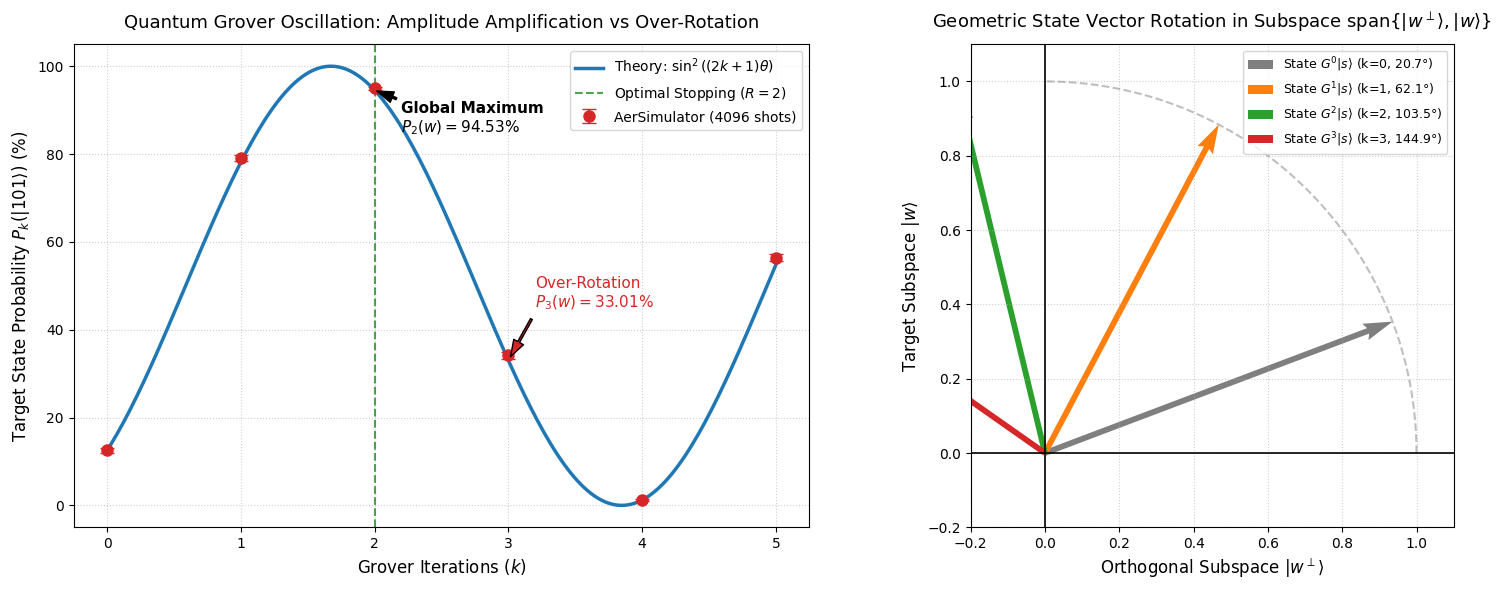

In [54]:
# 6. GROVER OSCILLATION AND GEOMETRIC ROTATION DYNAMICS

iteration_range = list(range(0, 6))
target_pattern = "101"
simulated_probs = []
std_errors = []

# Collect empirical data for k = 0, 1, 2, 3, 4, 5
for k in iteration_range:
    res = execute_pattern_search(target_pattern=target_pattern, iterations=k, shots=4096, seed_simulator=42)
    simulated_probs.append(res['empirical_prob'])
    std_errors.append(res['std_error'])

# Continuous theoretical curve
theta_val = np.arcsin(1 / np.sqrt(8))
k_fine = np.linspace(0, 5, 200)
p_theory_fine = np.sin((2 * k_fine + 1) * theta_val) ** 2
p_theory_discrete = [np.sin((2 * k + 1) * theta_val) ** 2 for k in iteration_range]

# Create Dual-Panel Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


# Panel 1: Probability Oscillation vs Iterations

ax1.plot(k_fine, p_theory_fine * 100, label=r'Theory: $\sin^2((2k+1)\theta)$', color='#1f77b4', lw=2.5)
ax1.errorbar(
    iteration_range,
    np.array(simulated_probs) * 100,
    yerr=np.array(std_errors) * 100,
    fmt='o',
    color='#d62728',
    capsize=5,
    markersize=8,
    label='AerSimulator (4096 shots)'
)
ax1.axvline(x=2, color='green', linestyle='--', alpha=0.7, label=r'Optimal Stopping ($R=2$)')
ax1.annotate(
    f"Global Maximum\n$P_2(w) = {p_theory_discrete[2]*100:.2f}\\%$",
    xy=(2, p_theory_discrete[2] * 100),
    xytext=(2.2, 85),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
    fontsize=11,
    fontweight='semibold'
)
ax1.annotate(
    f"Over-Rotation\n$P_3(w) = {p_theory_discrete[3]*100:.2f}\\%$",
    xy=(3, p_theory_discrete[3] * 100),
    xytext=(3.2, 45),
    arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=8),
    fontsize=11,
    color='#d62728'
)
ax1.set_xlabel('Grover Iterations ($k$)', fontsize=12)
ax1.set_ylabel(r'Target State Probability $P_k(|101\rangle)$ (%)', fontsize=12)
ax1.set_title("Quantum Grover Oscillation: Amplitude Amplification vs Over-Rotation", fontsize=13, pad=12)
ax1.set_xticks(iteration_range)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=10)


# Panel 2: Geometric State Vector Rotation in 2D Subspace

phi_arc = np.linspace(0, np.pi/2, 100)
ax2.plot(np.cos(phi_arc), np.sin(phi_arc), color='gray', linestyle='--', alpha=0.5)

colors = ['#7f7f7f', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for k in range(4):
    angle = (2 * k + 1) * theta_val
    vx = np.cos(angle)
    vy = np.sin(angle)
    ax2.quiver(
        0, 0, vx, vy, angles='xy', scale_units='xy', scale=1,
        color=colors[k], width=0.012,
        label=f"State $G^{k}|s\\rangle$ (k={k}, {angle*180/np.pi:.1f}°)"
    )

ax2.axhline(0, color='black', lw=1.2)
ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlim(-0.2, 1.1)
ax2.set_ylim(-0.2, 1.1)
ax2.set_aspect('equal')
ax2.set_xlabel(r'Orthogonal Subspace $|w^\perp\rangle$', fontsize=12)
ax2.set_ylabel(r'Target Subspace $|w\rangle$', fontsize=12)
ax2.set_title(r"Geometric State Vector Rotation in Subspace $\text{span}\{|w^\perp\rangle, |w\rangle\}$", fontsize=13, pad=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


# 8. Interactive Pattern Search Dashboard (Google Colab Application)

The interactive control dashboard below allows dynamic pattern search execution. Users can:
1. Select any 3-bit pattern from the dropdown menu (e.g., `000`, `011`, `101`, `110`) or enter a custom pattern.
2. Select the Grover iteration count $R \in \{1, 2, 3\}$.
3. Choose the measurement shot budget.
4. Inspect the dynamic quantum circuit diagram, probability distribution, and diagnostic summary in real time.


In [55]:
# 7. INTERACTIVE GOOGLE COLAB DASHBOARD

def interactive_quantum_search(
    target_pattern: str,
    iterations: int = 2,
    shots: int = 2048
):
    """
    Interactive GUI callback for Google Colab and Jupyter environments.
    """
    try:
        report = execute_pattern_search(
            target_pattern=target_pattern,
            iterations=iterations,
            shots=shots
        )
    except Exception as e:
        print(f"[ERROR] Circuit synthesis failed: {e}")
        return

    # Visual Display
    html_card = (
        '<div style="background-color: #f4f6f9; border-left: 5px solid #2b5797; padding: 12px 18px; margin: 10px 0; border-radius: 4px;">'
        + f'<h3 style="margin-top:0; color: #2b5797;">Quantum Pattern Search Report: Target |{report["target_pattern"]}></h3>'
        + f'<p style="margin: 4px 0;"><b>Algorithm Outcome:</b> <span style="color: {"green" if report["success"] else "red"}; font-weight: bold;">{report["identified_pattern"]} ({"MATCH" if report["success"] else "MISMATCH"})</span></p>'
        + f'<p style="margin: 4px 0;"><b>Target Measurement Probability:</b> {report["empirical_prob"]*100:.2f}% (Theoretical: {report["theoretical_prob"]*100:.2f}%)</p>'
        + f'<p style="margin: 4px 0;"><b>Grover Iterations:</b> {iterations} | <b>Sample Shots:</b> {shots}</p>'
        + '</div>'
    )
    display(HTML(html_card))

    print("\nSynthesized Quantum Circuit:")
    print(report['circuit'].draw(output='text'))

    fig = plot_histogram(
        report['counts'],
        title=f"Measurement Distribution -- Target |{target_pattern}> ({iterations} Iterations)",
        color="#2b5797"
    )
    display(fig)

# Instantiate interactive widget
pattern_selector = widgets.Dropdown(
    options=["000", "001", "010", "011", "100", "101", "110", "111"],
    value="101",
    description="Target:",
    disabled=False
)

iteration_slider = widgets.IntSlider(
    value=2,
    min=1,
    max=4,
    step=1,
    description="Iterations (R):",
    continuous_update=False
)

shots_selector = widgets.Dropdown(
    options=[512, 1024, 2048, 4096],
    value=2048,
    description="Shots:",
    disabled=False
)

ui = widgets.VBox([widgets.HBox([pattern_selector, iteration_slider, shots_selector])])
out = widgets.interactive_output(
    interactive_quantum_search,
    {'target_pattern': pattern_selector, 'iterations': iteration_slider, 'shots': shots_selector}
)

display(ui, out)


Output()

# 9. Scientific Explanation

> **How does your application use superposition, an oracle, phase marking, interference, and amplitude amplification to identify the target pattern?**
>
> 1. **Superposition**: The Hadamard transform $H^{\otimes 3}$ initializes an equiprobable state vector $|s\rangle = \frac{1}{\sqrt{8}}\sum_{x=0}^7 |x\rangle$, mapping the search space into an 8-state coherent quantum parallel superposition.
> 2. **Oracle**: A dynamic unitary operator $U_w$ is synthesized via bit-conditional Pauli-$X$ conjugation around a multi-controlled phase gate ($CCZ$), targeting $|w\rangle$ dynamically without hardcoding.
> 3. **Phase Marking**: Rather than altering probabilities directly, the oracle applies a selective Householder reflection $U_w|x\rangle = (-1)^{\delta_{x,w}}|x\rangle$, shifting the relative phase of the target pattern by $\pi$ radians while leaving non-target states invariant.
> 4. **Interference**: The diffusion operator $U_s = 2|s\rangle\langle s| - I$ reflects state vectors about the mean amplitude $\mu = \frac{1}{8}\sum_x a_x$, triggering destructive quantum interference that cancels out non-target probability amplitudes.
> 5. **Amplitude Amplification**: Concurrently, the inverted negative amplitude of the marked target state undergoes constructive interference, flipping about the mean ($a_w \mapsto 2\mu - a_w$) and boosting its magnitude.
> 6. **Subspace Evolution**: In the 2D invariant subspace $\text{span}\{|w^\perp\rangle, |w\rangle\}$, each Grover iteration rotates the quantum state toward $|w\rangle$ by $2\theta \approx 41.41^\circ$, achieving an analytical detection probability of $\frac{121}{128} \approx 94.53\%$ after exactly $R = 2$ iterations.
> 7. **Measurement Readout**: Projective computational basis measurement collapses the amplified wave function with near certainty ($>94\%$) onto the classical 3-bit register matching the user's target pattern.


# 10. Conclusion

## Investigation Summary:
- **Complexity Advantage**: Classical search across $N = 8$ items requires on average $\frac{N+1}{2} = 4.5$ queries (and $8$ queries worst-case). The quantum pattern search reliably isolates the target state in $R = 2$ queries, demonstrating quadratic quantum advantage $\mathcal{O}(\sqrt{N})$.
- **Architectural Generality**: Preconditioned conjugation $U_w = V_w^\dagger (CCZ) V_w$ provides a mathematically rigorous, fully automated oracle synthesis pipeline valid for any target pattern $w \in \{0, 1\}^n$ without manual circuit reconfiguration.
- **Interference Dynamics**: Both analytical derivation and `AerSimulator` sampling confirm that two iterations represent the optimal global stopping criterion ($94.53\%$ fidelity), while higher iteration counts induce quantum over-rotation and destructive interference.

---
